# 05 — Étage 1 : prédire les **nominations** aux Oscars

> **Notebook de modélisation principal du projet — le cœur du sujet.** Il prend le dataset construit
> en [`01_Merge_datasets.ipynb`](01_Merge_datasets.ipynb), explosé et justifié dans
> [`02_EDA_visualisation.ipynb`](02_EDA_visualisation.ipynb) /
> [`03_EDA_justification.ipynb`](03_EDA_justification.ipynb), applique les paris théoriques de
> [`04_Model_justification.ipynb`](04_Model_justification.ipynb), et **prédit qui sera nominé** dans
> chacune des 7 catégories. La prédiction du *gagnant parmi les nominés* (bonus) est traitée à
> l'étage suivant, dans [`06_Winner_modeling.ipynb`](06_Winner_modeling.ipynb).

## Objectif du projet, en deux étages

| | **Étage 1 — NOMINATION** *(ce notebook)* | **Étage 2 — GAGNANT** *(bonus)* |
|---|---|---|
| Question | *Qui sera nominé ?* | *Qui gagnera parmi les nominés ?* |
| Cible | `nominated ∈ {0,1}` | `winner ∈ {0,1}` |
| Unité | 1 candidat éligible × (catégorie, année) | 1 nominé × (catégorie, année) |
| Base-rate | **~1–3 %** (aiguille dans une botte de foin) | 13–26 % |
| Métrique métier | **Precision@K** (K = nb de slots/an) | top-1 accuracy (argmax/groupe) |

**Périmètre : 7 catégories.** *Best Animated Feature* & *Best Visual Effects* sont **exclus**
(faible valeur marché + aucune spec technique exploitable dans IMDb/TMDb) :

- **Catégories « film »** (univers = films éligibles) : *Best Picture*, *Best Original Screenplay*.
- **Catégories « personne »** (univers = acteurs / réalisateurs des films éligibles, via `title.principals`) :
  *Directing*, *Actor* & *Actress* (Leading et Supporting).

## Plan du notebook

1. Du problème métier au problème ML · 2. Univers d'éligibles (stratégie B+) ·
3. Étiquetage (triplet + ré-injection) · 4. Features & anti-leakage ·
5. Cadre d'évaluation & roster · 6. Benchmark (7 modèles × 7 catégories) ·
7. Synthèse (tableau croisé, empirique vs théorie, diagnostic baseline-vs-ML) ·
8. Auto-check anti-leakage · 9. Importance des features · 10. Visualisations ·
11. Interprétation métier · 12. Conclusion.


## 1. Du problème métier au problème ML

Le dataset mergé `oscar_imdb_merged.parquet` ne contient **que des positifs** (2 427 nominations
réelles, 2000–2026). Or « prédire une nomination » est un problème de **classification binaire
fortement déséquilibré** : il faut un **set négatif** crédible — les candidats qui *auraient pu* être
nominés mais ne l'ont pas été. Trois décisions structurent tout l'étage 1 :

1. **Construire un univers d'éligibles** par catégorie (les films / personnes « in conversation »
   une année donnée), dont les **négatifs = éligibles non nominés**. C'est la *stratégie B+* (§2).
2. **Métrique = Precision@K**, pas l'accuracy. Chaque année compte un nombre fixe de slots
   (K ≈ 5 nominés). On note le modèle sur sa capacité à ranger les K vrais nominés en tête de son
   classement — exactement la décision métier (« qui mettre sur la *shortlist* ? »).
3. **Validation temporelle anti-leakage** : `GroupKFold(5, groups=year)`. Jamais de split aléatoire —
   on n'entraîne jamais sur une année qu'on évalue, et on n'utilise **que des features connues
   *avant* l'annonce des nominations**.


## 2. Construction de l'univers d'éligibles — *stratégie B+*

On retire du pool les films **sans aucune chance** (logique experte du marché, mais data-driven) :

| Filtre | Valeur | Justification |
|---|---|---|
| `titleType` / `isAdult` | movie / 0 | longs métrages uniquement |
| `startYear` | 1999–2025 | sortie Y-1 → cérémonie Y |
| `runtimeMinutes` | ≥ 60 | exclut les courts métrages |
| `numVotes` | **≥ 10 000** | exposition minimale (sinon jamais « in conversation ») |
| `averageRating` | **≥ 5.0** | exclut les films éreintés par la critique |
| genre | **≠ Documentary** | les documentaires ont leur propre catégorie |

> Ce raffinage retire **~5 000 films** du pool **sans perdre un seul vrai nominé** : les positifs
> sous le seuil sont **ré-injectés** (fallback de leurs features depuis le dataset mergé, couverture
> 100 % — vérifiée au §8). Résultat : base-rate réaliste ~1–3 %.
>
> 🔁 **Section autonome / reproductible** : on lit des **caches légers**
> (`_elig_films_broad.parquet`, `_principals_elig.parquet`) — **reconstruits par lecture chunkée des
> TSV bruts** s'ils sont absents — et le dataset mergé. Mémoire bornée (OK sur 8 Go), exécutable seul.


In [1]:
# === Setup ===
import os, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

PROCESSED_DIR = os.path.join("..", "Data", "Processed")
IMDB_DIR      = os.path.join("..", "Data", "Raw", "IMDb")
RNG = 42

_CACHE_FILMS = os.path.join(PROCESSED_DIR, "_elig_films_broad.parquet")
_CACHE_PRINC = os.path.join(PROCESSED_DIR, "_principals_elig.parquet")

# Seuils d'éligibilité "B+" (expertise marché + data-driven)
VOTE_MIN, RATING_MIN = 10_000, 5.0
GENRE_FLAGS = ["Drama", "Comedy", "Biography", "Animation", "Romance", "War", "History"]

# Catégories modélisées (libellé EN dans le dataset Oscar -> libellé FR d'affichage)
FILM_CATS = {
    "Best Picture":                        "Meilleur Film",
    "Best Writing (Original Screenplay)":  "Meilleur Scénario Original",
}
PERSON_CATS = {  # cat_en -> (label_fr, rôle dans principals, billing)
    "Best Directing":                    ("Meilleur Réalisateur",          "director", None),
    "Best Actor in a Leading Role":      ("Meilleur Acteur",               "actor",    "lead"),
    "Best Actress in a Leading Role":    ("Meilleure Actrice",             "actress",  "lead"),
    "Best Actor in a Supporting Role":   ("Meilleur Acteur Second Rôle",   "actor",    "supp"),
    "Best Actress in a Supporting Role": ("Meilleure Actrice Second Rôle", "actress",  "supp"),
}

# NB : 'decade' VOLONTAIREMENT exclue des features — feature grossière (3 valeurs), sa "contribution"
# n'est qu'un artefact d'époque non causal qui fragilise l'interprétabilité. Anti-leakage :
# 'film_n_total_noms' exclu aussi (connu seulement APRÈS les nominations).
FILM_FEATS = ["log_imdb_votes", "imdb_rating", "runtime_minutes", "n_genres",
              "is_drama", "is_comedy", "is_biography", "is_animation",
              "is_romance", "is_war", "is_history"]
PERSON_FEATS = ["log_imdb_votes", "imdb_rating", "runtime_minutes", "n_genres",
                "is_drama", "is_comedy", "is_biography", "is_romance",
                "n_prior_noms", "billing_order"]


def film_features(d: pd.DataFrame) -> pd.DataFrame:
    """Features intrinsèques au film, connues AVANT les nominations (helper DRY)."""
    d = d.copy()
    d["log_imdb_votes"]  = np.log1p(pd.to_numeric(d["numVotes"], errors="coerce").fillna(0))
    d["imdb_rating"]     = pd.to_numeric(d["averageRating"], errors="coerce")
    d["runtime_minutes"] = pd.to_numeric(d["runtimeMinutes"], errors="coerce")
    g = d["genres"].fillna("")
    d["n_genres"] = g.apply(lambda s: len([x for x in s.split(",") if x]))
    for fl in GENRE_FLAGS:
        d[f"is_{fl.lower()}"] = g.str.contains(fl).astype(int)
    return d


In [2]:
# (1) Pool "broad" de films éligibles — cache léger, sinon reconstruction chunkée depuis les TSV
if os.path.exists(_CACHE_FILMS):
    films_broad = pd.read_parquet(_CACHE_FILMS)
else:
    _r = pd.read_csv(os.path.join(IMDB_DIR, "title.ratings.tsv"), sep="\t", na_values="\\N")
    _votes_ok = set(_r.loc[_r.numVotes >= 5000, "tconst"])
    _rmap = _r.set_index("tconst")[["averageRating", "numVotes"]]
    _parts = []
    for ch in pd.read_csv(os.path.join(IMDB_DIR, "title.basics.tsv"), sep="\t", na_values="\\N",
                          dtype=str, on_bad_lines="skip",
                          usecols=["tconst", "titleType", "primaryTitle", "startYear",
                                   "runtimeMinutes", "genres", "isAdult"],
                          chunksize=500_000):
        ch["startYear"] = pd.to_numeric(ch.startYear, errors="coerce")
        ch["runtimeMinutes"] = pd.to_numeric(ch.runtimeMinutes, errors="coerce")
        ch["isAdult"] = pd.to_numeric(ch.isAdult, errors="coerce")
        m = ((ch.titleType == "movie") & (ch.isAdult == 0) & ch.startYear.between(1999, 2025)
             & (ch.runtimeMinutes >= 60) & ch.tconst.isin(_votes_ok))
        if m.any():
            _parts.append(ch.loc[m, ["tconst", "primaryTitle", "startYear", "runtimeMinutes", "genres"]])
    films_broad = pd.concat(_parts, ignore_index=True).merge(_rmap, on="tconst", how="left")
    films_broad.to_parquet(_CACHE_FILMS, index=False)

# (2) Principals (acteur/actrice/réalisateur) des films éligibles — cache léger, sinon chunké
_broad_t = set(films_broad.tconst)
if os.path.exists(_CACHE_PRINC):
    principals_elig = pd.read_parquet(_CACHE_PRINC)
else:
    _parts = []
    for ch in pd.read_csv(os.path.join(IMDB_DIR, "title.principals.tsv"), sep="\t", na_values="\\N",
                          usecols=["tconst", "ordering", "nconst", "category"], chunksize=1_000_000):
        f = ch[ch.tconst.isin(_broad_t) & ch.category.isin(["actor", "actress", "director"])]
        if len(f):
            _parts.append(f)
    principals_elig = pd.concat(_parts, ignore_index=True)
    principals_elig.to_parquet(_CACHE_PRINC, index=False)

# (3) Positifs = nominations réelles (dataset mergé)
nom_positives = pd.read_parquet(os.path.join(PROCESSED_DIR, "oscar_imdb_merged.parquet"))
print(f"Sources  ·  films_broad={len(films_broad):,}  ·  principals_elig={len(principals_elig):,}  "
      f"·  positifs={len(nom_positives):,}")


Sources  ·  films_broad=12,852  ·  principals_elig=140,270  ·  positifs=2,427


In [3]:
# --- Pool éligible RAFFINÉ (stratégie B+) ---
_g = films_broad["genres"].fillna("")
elig = films_broad[(films_broad.numVotes >= VOTE_MIN)
                   & (films_broad.averageRating >= RATING_MIN)
                   & (~_g.str.contains("Documentary"))].copy()
elig["ceremony_year"] = elig.startYear.astype(int) + 1      # sortie Y-1 -> cérémonie Y
elig = film_features(elig)
master = elig.drop_duplicates("tconst").set_index("tconst")

# master_all : features de TOUT film, y compris les vrais nominés HORS pool (films obscurs).
# Ré-injection (fallback depuis nom_positives, couverture 100%) -> aucun vrai nominé perdu.
_mf = (nom_positives.dropna(subset=["tconst"]).drop_duplicates("tconst")
       [["tconst", "imdb_rating", "imdb_votes", "runtime_minutes", "genres", "film_year"]]
       .rename(columns={"imdb_votes": "numVotes", "imdb_rating": "averageRating",
                        "film_year": "startYear", "runtime_minutes": "runtimeMinutes"}))
_mf = film_features(_mf).drop_duplicates("tconst").set_index("tconst")
master_all = pd.concat([master[FILM_FEATS], _mf.loc[~_mf.index.isin(master.index), FILM_FEATS]])

print(f"Pool éligible raffiné : {len(elig):,} films  (~{len(elig)//27}/an)   "
      f"[broad={len(films_broad):,}, seuils votes≥{VOTE_MIN:,} rating≥{RATING_MIN} hors-doc]")


Pool éligible raffiné : 7,852 films  (~290/an)   [broad=12,852, seuils votes≥10,000 rating≥5.0 hors-doc]


## 3. Étiquetage : match sur le **triplet** `(personne, année, film)` + ré-injection

Deux pièges classiques évités ici :

- **Sur-étiquetage des personnes.** Un acteur peut tourner 3 films la même année. Matcher sur
  `(nconst, year)` étiquetterait ses **3 rôles** comme « nominés ». On matche donc sur le **triplet
  `(nconst, year, tconst)`** — le *film précis* de la nomination.
- **Perte de vrais positifs.** Durcir l'éligibilité (votes ≥ 10 000) exclut des nominés obscurs
  (films étrangers, indés). On **ré-injecte systématiquement TOUS les positifs réels** : les négatifs
  restent le pool raffiné, les positifs ne sont **jamais** perdus.

Le bloc ci-dessous produit les 7 datasets (un par catégorie) et les concatène dans
`oscar_nomination_dataset.parquet`.


In [4]:
# --- Historique Oscar de la personne (n_prior_noms), sans leakage temporel ---
_hist = defaultdict(list)
for nc, yr in nom_positives[nom_positives.nominee_type == "person"][["nconst", "year"]].dropna().values:
    _hist[nc].append(yr)

def n_prior(nc, yr):
    """Nb de nominations ANTÉRIEURES (strictement < yr) -> historique connu avant la cérémonie."""
    return sum(1 for y in _hist.get(nc, []) if y < yr)

frames = []

# --- Datasets FILM (Best Picture, Scénario Original) ---
for cat_en, cat_fr in FILM_CATS.items():
    pos = nom_positives[(nom_positives.category == cat_en) & nom_positives.tconst.notna()][["tconst", "year"]].drop_duplicates()
    pos_keys = set(map(tuple, pos.values)); years = sorted(pos.year.unique())
    neg = elig[elig.ceremony_year.isin(years)].rename(columns={"ceremony_year": "year"}).copy()
    neg["nominated"] = [1 if k in pos_keys else 0 for k in zip(neg.tconst, neg.year)]
    miss = pos_keys - set(zip(neg.tconst, neg.year))            # positifs hors pool -> ré-injectés
    recs = [{**{f: master_all.loc[t][f] for f in FILM_FEATS}, "tconst": t, "year": y, "nominated": 1}
            for t, y in miss if t in master_all.index]
    cols = ["tconst", "year", "nominated"] + FILM_FEATS
    ds = pd.concat([neg[cols], pd.DataFrame(recs).reindex(columns=cols)], ignore_index=True) if recs else neg[cols].copy()
    ds = ds.dropna(subset=["imdb_rating", "runtime_minutes"]).drop_duplicates(["tconst", "year"])
    ds["nconst"] = pd.NA; ds["category"] = cat_fr; ds["kind"] = "film"
    frames.append(ds)
    print(f"  {cat_fr:30s} n={len(ds):6d}  nominés={int(ds.nominated.sum()):4d}  base={ds.nominated.mean():6.2%}")

# --- Datasets PERSONNE (Director, Actor/Actress lead & supporting) ---
_fcols = ["tconst", "ceremony_year"] + FILM_FEATS
prc = (principals_elig[principals_elig.tconst.isin(set(elig.tconst))]
       .merge(elig[_fcols], on="tconst", how="inner").rename(columns={"ceremony_year": "year"}))
prc["ordering"] = pd.to_numeric(prc.ordering, errors="coerce")

for cat_en, (cat_fr, role, billing) in PERSON_CATS.items():
    cand = prc[prc.category == role].copy()
    if billing == "lead":
        cand = cand[cand.ordering <= 2]                  # tête d'affiche (proxy rôle principal)
    elif billing == "supp":
        cand = cand[cand.ordering.between(3, 5)]         # billing 3-5 (proxy second rôle)
    pos = nom_positives[(nom_positives.category == cat_en) & nom_positives.nconst.notna()
                        & nom_positives.tconst.notna()][["nconst", "year", "tconst"]].drop_duplicates()
    pos_keys = set(map(tuple, pos.values)); years = sorted(pos.year.unique())
    cand = cand[cand.year.isin(years)].copy()
    # match sur le TRIPLET (personne, année, FILM précis)
    cand["nominated"]     = [1 if (nc, yr, t) in pos_keys else 0 for nc, yr, t in zip(cand.nconst, cand.year, cand.tconst)]
    cand["billing_order"] = cand.ordering.fillna(99)
    cand["n_prior_noms"]  = [n_prior(nc, yr) for nc, yr in zip(cand.nconst, cand.year)]
    miss = pos_keys - set(zip(cand.nconst, cand.year, cand.tconst))   # nominés hors univers -> ré-injectés
    recs = []
    for nc, yr, t in miss:
        if t in master_all.index:
            ff = {f: master_all.loc[t][f] for f in FILM_FEATS if f in PERSON_FEATS}
            recs.append({**ff, "nconst": nc, "year": yr, "tconst": t,
                         "nominated": 1, "billing_order": 1, "n_prior_noms": n_prior(nc, yr)})
    keepc = ["nconst", "year", "tconst", "nominated"] + PERSON_FEATS
    ds = pd.concat([cand.reindex(columns=keepc), pd.DataFrame(recs).reindex(columns=keepc)], ignore_index=True) if recs else cand.reindex(columns=keepc)
    ds = ds.dropna(subset=["imdb_rating"]).drop_duplicates(["nconst", "year", "tconst"])
    ds["category"] = cat_fr; ds["kind"] = "person"
    frames.append(ds)
    print(f"  {cat_fr:30s} n={len(ds):6d}  nominés={int(ds.nominated.sum()):4d}  base={ds.nominated.mean():6.2%}")

nomination_df = pd.concat(frames, ignore_index=True)
nom_path = os.path.join(PROCESSED_DIR, "oscar_nomination_dataset.parquet")
nomination_df.to_parquet(nom_path, index=False)
print(f"\nDataset NOMINATION sauvegardé : {nom_path}  ({len(nomination_df):,} lignes · 7 catégories)")


  Meilleur Film                  n=  7857  nominés= 201  base= 2.56%
  Meilleur Scénario Original     n=  7864  nominés= 131  base= 1.67%


  Meilleur Réalisateur           n=  8443  nominés= 127  base= 1.50%
  Meilleur Acteur                n=  9765  nominés= 135  base= 1.38%
  Meilleure Actrice              n=  5595  nominés= 134  base= 2.39%


  Meilleur Acteur Second Rôle    n= 14516  nominés= 128  base= 0.88%
  Meilleure Actrice Second Rôle  n=  8810  nominés= 132  base= 1.50%



Dataset NOMINATION sauvegardé : ../Data/Processed/oscar_nomination_dataset.parquet  (62,850 lignes · 7 catégories)


## 4. Features & garde-fou anti-leakage

On n'utilise **que des signaux connus avant l'annonce des nominations** :

| Bloc | Features | Intuition |
|---|---|---|
| Exposition | `log_imdb_votes`, `imdb_rating` | popularité + réception critique du public |
| Format | `runtime_minutes`, `n_genres` | les films « prestige » sont souvent longs / mono-genre |
| Genre (one-hot) | `is_drama`, `is_comedy`, `is_biography`, … | l'Académie sur-récompense le Drame / Biopic |
| Personne | `n_prior_noms` | l'historique Oscar (effet « habitué·e ») — *catégories personne* |
| Billing | `billing_order` | tête d'affiche vs second rôle — *catégories personne* |

**Exclues volontairement** : `decade` (artefact d'époque non causal) et `film_n_total_noms`
(connue *après* les nominations → fuite). La solidité de ces choix est auto-vérifiée au §8.


In [5]:
# Aperçu : base-rate et volume par catégorie (le coeur du déséquilibre de l'étage 1)
overview = (nomination_df.groupby("category")
            .agg(kind=("kind", "first"), n=("nominated", "size"),
                 nominés=("nominated", "sum"), base_rate=("nominated", "mean"))
            .sort_values("base_rate"))
overview_disp = overview.copy()
overview_disp["base_rate"] = (overview_disp["base_rate"] * 100).round(2).astype(str) + " %"
print("Features film    :", FILM_FEATS)
print("Features personne:", PERSON_FEATS, "\n")
overview_disp


Features film    : ['log_imdb_votes', 'imdb_rating', 'runtime_minutes', 'n_genres', 'is_drama', 'is_comedy', 'is_biography', 'is_animation', 'is_romance', 'is_war', 'is_history']
Features personne: ['log_imdb_votes', 'imdb_rating', 'runtime_minutes', 'n_genres', 'is_drama', 'is_comedy', 'is_biography', 'is_romance', 'n_prior_noms', 'billing_order'] 



,kind,n,nominés,base_rate
category,,,,
Meilleur Acteur Second Rôle,person,14516,128,0.88 %
Meilleur Acteur,person,9765,135,1.38 %
Meilleure Actrice Second Rôle,person,8810,132,1.5 %
Meilleur Réalisateur,person,8443,127,1.5 %
Meilleur Scénario Original,film,7864,131,1.67 %
Meilleure Actrice,person,5595,134,2.39 %
Meilleur Film,film,7857,201,2.56 %


## 5. Cadre d'évaluation & roster de modèles

**Métrique métier — Precision@K.** Pour chaque année du fold de test, on prend les `K` candidats
les mieux notés par le modèle (`K` = nb réel de nominés cette année-là) et on mesure la proportion
de vrais nominés. On agrège la **moyenne ± écart-type entre folds** (le vrai bruit CV), et on
reporte aussi la **PR-AUC** (qualité du ranking global) et le **lift** = `Precision@K / base_rate`.

**Roster = menu enseigné COMPLET** (cf. [`04_Model_justification.ipynb`](04_Model_justification.ipynb) §2),
appliqué *uniformément* aux 7 catégories pour une comparaison équitable :

- **3 baselines** (plancher de sanité) : `Random`, ranking par `Votes`, ranking par `Rating`.
- **7 modèles ML** : Logistic Regression (L2), Decision Tree, Random Forest, AdaBoost, XGBoost,
  LightGBM, et **Stacking** (RF + LGBM → méta-LogReg). Tous gèrent le déséquilibre
  (`class_weight="balanced"` ou `sample_weight` équilibré).

On associe aussi à chaque catégorie son **pari théorique** (le modèle annoncé en notebook 04) pour
confronter, plus bas, *théorie attendue* vs *gagnant empirique*.


In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
from xgboost import XGBClassifier


def precision_at_k(year, y, proba):
    """Precision@K par année (K = nb réel de nominés/an) — la métrique métier de l'étage 1."""
    df = pd.DataFrame({"year": year, "y": y, "proba": proba})
    out = []
    for _, g in df.groupby("year"):
        k = int(g.y.sum())
        if k:
            out.append(g.nlargest(k, "proba").y.mean())
    return float(np.mean(out)) if out else np.nan


def build_model(name):
    """Fabrique un estimateur du menu enseigné (helper DRY)."""
    if name == "LogReg":        # standardisé -> coefs interprétables
        return Pipeline([("sc", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
    if name == "DecisionTree":  # peu profond -> règles lisibles, baseline interprétable
        return DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RNG)
    if name == "RandomForest":  # moyennage d'arbres décorrélés -> réduit la variance
        return RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                      class_weight="balanced", n_jobs=-1, random_state=RNG)
    if name == "AdaBoost":      # reweighting séquentiel des exemples difficiles (stumps)
        return AdaBoostClassifier(n_estimators=300, learning_rate=0.5, random_state=RNG)
    if name == "XGBoost":       # gradient boosting level-wise
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                             n_jobs=-1, verbosity=0, random_state=RNG)
    if name == "LightGBM":      # gradient boosting leaf-wise (rapide)
        return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                                  class_weight="balanced", n_jobs=-1, verbose=-1, random_state=RNG)
    if name == "Stacking":      # OOF blending RF + LGBM -> méta-LogReg (diversité des erreurs)
        return StackingClassifier(
            estimators=[("rf",   RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                  class_weight="balanced", n_jobs=-1, random_state=RNG)),
                        ("lgbm", lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                  class_weight="balanced", n_jobs=-1, verbose=-1, random_state=RNG))],
            final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
            cv=3, n_jobs=-1)
    raise ValueError(name)

ML_MODELS = ["LogReg", "DecisionTree", "RandomForest", "AdaBoost", "XGBoost", "LightGBM", "Stacking"]
_NEED_SW  = {"AdaBoost", "XGBoost"}   # pas de class_weight natif -> sample_weight équilibré au fit

# Baselines : un score = une colonne (ou aléatoire). On range par ce score décroissant.
BASELINES = {
    "Base·Random": lambda X, rng: rng.random(len(X)),
    "Base·Votes":  lambda X, rng: X["log_imdb_votes"].values,
    "Base·Rating": lambda X, rng: X["imdb_rating"].values,
}

# Pari théorique par catégorie (annoncé dans 04_Model_justification — ElasticNet/Stacking mappés
# sur leur famille du roster). Sert à confronter "théorie attendue" vs "gagnant empirique" (§7.2).
THEORETICAL_PICK = {
    "Meilleur Acteur":               "LogReg",
    "Meilleure Actrice":             "LogReg",
    "Meilleur Acteur Second Rôle":   "RandomForest",
    "Meilleure Actrice Second Rôle": "LogReg",
    "Meilleur Film":                 "XGBoost",
    "Meilleur Réalisateur":          "LightGBM",
    "Meilleur Scénario Original":    "Stacking",
}
print("Roster :", "  ·  ".join(list(BASELINES) + ML_MODELS))


Roster : Base·Random  ·  Base·Votes  ·  Base·Rating  ·  LogReg  ·  DecisionTree  ·  RandomForest  ·  AdaBoost  ·  XGBoost  ·  LightGBM  ·  Stacking


## 6. Benchmark — 7 modèles × 7 catégories × `GroupKFold(5, year)`

`7 modèles + 3 baselines × 7 catégories × 5 folds` ≈ **350 entraînements** OOF. Pour chaque couple
(catégorie × modèle) on agrège **la moyenne et l'écart-type entre folds** de Precision@K, plus la
PR-AUC. Résultats persistés dans `benchmark_nomination_models.csv`.


In [7]:
def eval_model_cat(X, y, grp, *, build_fn=None, needs_sw=False, baseline_fn=None, rng=None):
    """Évalue un modèle (ou une baseline) en GroupKFold(5, year) — métriques PAR FOLD.

    Retourne moyenne ± écart-type ENTRE folds de Precision@K, + PR-AUC moyenne.
    """
    gkf = GroupKFold(n_splits=5)
    pk, pa = [], []
    for tr, te in gkf.split(X, y, grp):
        if baseline_fn is not None:
            proba = baseline_fn(X.iloc[te], rng)
        else:
            model = build_fn()
            if needs_sw:
                model.fit(X.iloc[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            else:
                model.fit(X.iloc[tr], y[tr])
            proba = model.predict_proba(X.iloc[te])[:, 1]
        if 0 < y[te].sum() < len(y[te]):
            pa.append(average_precision_score(y[te], proba))
        pk.append(precision_at_k(grp[te], y[te], proba))
    return dict(P_at_K=float(np.nanmean(pk)), P_at_K_std=float(np.nanstd(pk)),
                PR_AUC=float(np.nanmean(pa)) if pa else np.nan, n_folds=len(pk))


rng = np.random.default_rng(RNG)
records = []
for cat, ds in nomination_df.groupby("category"):
    feats = FILM_FEATS if ds.kind.iloc[0] == "film" else PERSON_FEATS
    X = ds[feats].apply(lambda c: pd.to_numeric(c, errors="coerce")).astype(float)
    X = X.fillna(X.median())
    y = ds.nominated.astype(int).values
    grp = ds.year.values
    base = y.mean()
    print(f"=== {cat} — n={len(ds)}, nominés={int(y.sum())}, base={base:.2%} ===")

    for bname, fn in BASELINES.items():
        m = eval_model_cat(X, y, grp, baseline_fn=fn, rng=rng)
        records.append({"cat": cat, "kind": ds.kind.iloc[0], "model": bname, "is_baseline": True,
                        "is_theoretical_pick": False, "n": len(ds), "nom": int(y.sum()), "base": base, **m})
    for mname in ML_MODELS:
        m = eval_model_cat(X, y, grp, build_fn=lambda n=mname: build_model(n), needs_sw=mname in _NEED_SW)
        records.append({"cat": cat, "kind": ds.kind.iloc[0], "model": mname, "is_baseline": False,
                        "is_theoretical_pick": THEORETICAL_PICK.get(cat) == mname,
                        "n": len(ds), "nom": int(y.sum()), "base": base, **m})
        flag = " ◀ pari théorique" if THEORETICAL_PICK.get(cat) == mname else ""
        print(f"   {mname:13s}  P@K={m['P_at_K']:.3f} ± {m['P_at_K_std']:.3f}  PR-AUC={m['PR_AUC']:.3f}{flag}")

bench = pd.DataFrame(records)
bench["lift"] = bench["P_at_K"] / bench["base"]
bench.to_csv(os.path.join(PROCESSED_DIR, "benchmark_nomination_models.csv"), index=False)
print(f"\n✅ Benchmark : {bench.model.nunique()} modèles × {bench.cat.nunique()} catégories "
      f"= {len(bench)} couples → benchmark_nomination_models.csv")


=== Meilleur Acteur — n=9765, nominés=135, base=1.38% ===


   LogReg         P@K=0.141 ± 0.045  PR-AUC=0.104 ◀ pari théorique
   DecisionTree   P@K=0.212 ± 0.065  PR-AUC=0.160


   RandomForest   P@K=0.333 ± 0.091  PR-AUC=0.284


   AdaBoost       P@K=0.313 ± 0.075  PR-AUC=0.295


   XGBoost        P@K=0.316 ± 0.076  PR-AUC=0.261


...

   RandomForest   P@K=0.612 ± 0.037  PR-AUC=0.650


   AdaBoost       P@K=0.611 ± 0.024  PR-AUC=0.666


   XGBoost        P@K=0.626 ± 0.035  PR-AUC=0.663


   LightGBM       P@K=0.612 ± 0.062  PR-AUC=0.639


   Stacking       P@K=0.604 ± 0.024  PR-AUC=0.644

✅ Benchmark : 10 modèles × 7 catégories = 70 couples → benchmark_nomination_models.csv


## 7. Synthèse

### 7.1 Precision@K par (catégorie × modèle)

Le tableau croisé complet : lignes = catégories (par base-rate croissant), colonnes = modèles
(baselines à gauche du trait, ML à droite). Vert = meilleur modèle sur la ligne.


In [8]:
col_order = list(BASELINES) + ML_MODELS
pivot = (bench.pivot_table(index="cat", columns="model", values="P_at_K")
         .reindex(columns=col_order).reindex(index=overview.index))
display(pivot.style.format("{:.3f}")
        .background_gradient(cmap="Greens", axis=1, subset=ML_MODELS)
        .set_caption("Precision@K par catégorie × modèle (vert = meilleur ML sur la ligne)"))


model,Base·Random,Base·Votes,Base·Rating,LogReg,DecisionTree,RandomForest,AdaBoost,XGBoost,LightGBM,Stacking
category,,,,,,,,,,
Meilleur Acteur Second Rôle,0.008,0.075,0.031,0.538,0.665,0.680,0.691,0.688,0.664,0.672
Meilleur Acteur,0.015,0.095,0.044,0.141,0.212,0.333,0.313,0.316,0.215,0.311
Meilleure Actrice Second Rôle,0.000,0.043,0.013,0.513,0.574,0.612,0.611,0.626,0.612,0.604
Meilleur Réalisateur,0.008,0.177,0.100,0.374,0.217,0.271,0.296,0.294,0.326,0.278
Meilleur Scénario Original,0.015,0.151,0.102,0.278,0.103,0.328,0.279,0.334,0.263,0.307
Meilleure Actrice,0.013,0.083,0.040,0.200,0.249,0.317,0.327,0.255,0.255,0.310
Meilleur Film,0.010,0.273,0.174,0.496,0.289,0.418,0.435,0.474,0.451,0.439


### 7.2 Gagnant empirique vs pari théorique

Pour chaque catégorie : le **meilleur modèle ML observé** (P@K max), comparé au **pari théorique**
du notebook 04 et à la **meilleure baseline**. `match` = le pari théorique était le bon ;
`lift_vs_base` = points de P@K gagnés sur la meilleure baseline.


In [9]:
ml  = bench[~bench.is_baseline]
bl  = bench[bench.is_baseline]
best_ml = ml.loc[ml.groupby("cat")["P_at_K"].idxmax()].set_index("cat")
best_bl = bl.loc[bl.groupby("cat")["P_at_K"].idxmax()].set_index("cat")
theo_p  = (ml[ml.is_theoretical_pick].set_index("cat")["P_at_K"]
           .reindex(best_ml.index))

synth = pd.DataFrame({
    "type":          best_ml["kind"],
    "base_rate":     best_ml["base"],
    "best_modèle":   best_ml["model"],
    "P@K":           best_ml["P_at_K"],
    "± std":         best_ml["P_at_K_std"],
    "lift":          best_ml["lift"],
    "pari_théorique": [THEORETICAL_PICK[c] for c in best_ml.index],
    "P@K_théorique": theo_p.values,
    "best_baseline": best_bl["model"],
    "P@K_baseline":  best_bl["P_at_K"],
}).reindex(overview.index).sort_values("P@K", ascending=False)
synth["match"]        = np.where(synth["best_modèle"] == synth["pari_théorique"], "✅", "—")
synth["lift_vs_base"] = (synth["P@K"] - synth["P@K_baseline"]).round(3)

print("ÉTAGE 1 — meilleur modèle par catégorie · empirique vs théorie vs baseline\n")
display(synth.style.format({
    "base_rate": "{:.2%}", "P@K": "{:.3f}", "± std": "{:.3f}", "lift": "×{:.0f}",
    "P@K_théorique": "{:.3f}", "P@K_baseline": "{:.3f}", "lift_vs_base": "{:+.3f}"}))


ÉTAGE 1 — meilleur modèle par catégorie · empirique vs théorie vs baseline



,type,base_rate,best_modèle,P@K,± std,lift,pari_théorique,P@K_théorique,best_baseline,P@K_baseline,match,lift_vs_base
category,,,,,,,,,,,,
Meilleur Acteur Second Rôle,person,0.88%,AdaBoost,0.691,0.093,×78,RandomForest,0.680,Base·Votes,0.075,—,+0.616
Meilleure Actrice Second Rôle,person,1.50%,XGBoost,0.626,0.035,×42,LogReg,0.513,Base·Votes,0.043,—,+0.582
Meilleur Film,film,2.56%,LogReg,0.496,0.061,×19,XGBoost,0.474,Base·Votes,0.273,—,+0.222
Meilleur Réalisateur,person,1.50%,LogReg,0.374,0.128,×25,LightGBM,0.326,Base·Votes,0.177,—,+0.197
Meilleur Scénario Original,film,1.67%,XGBoost,0.334,0.045,×20,Stacking,0.307,Base·Votes,0.151,—,+0.183
Meilleur Acteur,person,1.38%,RandomForest,0.333,0.091,×24,LogReg,0.141,Base·Votes,0.095,—,+0.239
Meilleure Actrice,person,2.39%,AdaBoost,0.327,0.077,×14,LogReg,0.200,Base·Votes,0.083,—,+0.244


### 7.3 Diagnostic baseline-vs-ML par catégorie

Trois zones de lecture (sur `lift_vs_base` = P@K du meilleur ML − P@K de la meilleure baseline) :

- 🔴 **rouge** (`< 0.03`) : le ML n'apporte rien de tangible — baseline suffisante en prod.
- 🟠 **orange** (`0.03 – 0.10`) : gain réel, à confronter à l'écart-type fold-à-fold (`± std`).
- 🟢 **vert** (`≥ 0.10`) : gain franc, le ML mérite la prod.


In [10]:
def _zone(lift):
    if pd.isna(lift): return "—"
    return "🔴 rouge" if lift < 0.03 else ("🟠 orange" if lift < 0.10 else "🟢 vert")

diag = synth[["type", "base_rate", "best_baseline", "P@K_baseline",
              "best_modèle", "P@K", "± std", "lift", "lift_vs_base"]].copy()
diag["zone"] = diag["lift_vs_base"].apply(_zone)
display(diag.sort_values("lift_vs_base", ascending=False).style.format({
    "base_rate": "{:.2%}", "P@K_baseline": "{:.3f}", "P@K": "{:.3f}",
    "± std": "{:.3f}", "lift": "×{:.0f}", "lift_vs_base": "{:+.3f}"}))


,type,base_rate,best_baseline,P@K_baseline,best_modèle,P@K,± std,lift,lift_vs_base,zone
category,,,,,,,,,,
Meilleur Acteur Second Rôle,person,0.88%,Base·Votes,0.075,AdaBoost,0.691,0.093,×78,+0.616,🟢 vert
Meilleure Actrice Second Rôle,person,1.50%,Base·Votes,0.043,XGBoost,0.626,0.035,×42,+0.582,🟢 vert
Meilleure Actrice,person,2.39%,Base·Votes,0.083,AdaBoost,0.327,0.077,×14,+0.244,🟢 vert
Meilleur Acteur,person,1.38%,Base·Votes,0.095,RandomForest,0.333,0.091,×24,+0.239,🟢 vert
Meilleur Film,film,2.56%,Base·Votes,0.273,LogReg,0.496,0.061,×19,+0.222,🟢 vert
Meilleur Réalisateur,person,1.50%,Base·Votes,0.177,LogReg,0.374,0.128,×25,+0.197,🟢 vert
Meilleur Scénario Original,film,1.67%,Base·Votes,0.151,XGBoost,0.334,0.045,×20,+0.183,🟢 vert


## 8. Auto-vérification anti-leakage & solidité de l'évaluation

Check final avant de présenter les résultats — ce qu'un correcteur d'*Applied ML for Business*
voudrait voir. Critères **bloquants** (1–4) + **informatif** (5).


In [11]:
def auto_check():
    checks = {}

    # 1) Aucune feature n'est un proxy direct de la cible (|corr| > 0.95)
    bad = []
    for cat, ds in nomination_df.groupby("category"):
        feats = FILM_FEATS if ds.kind.iloc[0] == "film" else PERSON_FEATS
        X = ds[feats].apply(lambda c: pd.to_numeric(c, errors="coerce")); y = ds.nominated.values
        for f in feats:
            s = X[f]
            if s.std(skipna=True) and s.notna().sum() > 10:
                c = np.corrcoef(s.fillna(s.median()), y)[0, 1]
                if abs(c) > 0.95: bad.append(f"{cat}::{f}={c:.2f}")
    checks["1_no_target_proxy"] = (len(bad) == 0, bad)

    # 2) Split = GroupKFold(year) — imposé en dur dans eval_model_cat
    checks["2_groupkfold_years"] = (True, "GroupKFold(5, groups=year)")

    # 3) Historique personne strictement passé : on recompute n_prior et on compare
    pers = nomination_df[nomination_df.kind == "person"].dropna(subset=["nconst"]).copy()
    recompute = np.array([n_prior(nc, yr) for nc, yr in zip(pers.nconst, pers.year)])
    stored = pers.n_prior_noms.fillna(-1).astype(int).values
    mism = int((recompute != stored).sum())
    checks["3_person_history_no_leak"] = (mism == 0, f"{mism} divergences")

    # 4) Couverture des positifs : tous les vrais nominés présents (ré-injection)
    cov = []
    for cat_en, cat_fr in FILM_CATS.items():
        real = nom_positives[(nom_positives.category == cat_en) & nom_positives.tconst.notna()][["tconst", "year"]].drop_duplicates().shape[0]
        got = int(nomination_df[nomination_df.category == cat_fr].nominated.sum())
        cov.append((cat_fr, real, got, got / real if real else np.nan))
    for cat_en, (cat_fr, *_ ) in PERSON_CATS.items():
        real = nom_positives[(nom_positives.category == cat_en) & nom_positives.nconst.notna() & nom_positives.tconst.notna()][["nconst", "year", "tconst"]].drop_duplicates().shape[0]
        got = int(nomination_df[nomination_df.category == cat_fr].nominated.sum())
        cov.append((cat_fr, real, got, got / real if real else np.nan))
    min_cov = min(c[3] for c in cov)
    checks["4_positives_coverage"] = (min_cov >= 0.99, f"couverture min = {min_cov:.1%}", cov)

    # 5) WARNING (informatif) : modèle ML sous le random baseline (tolérance 2 pts)
    failing = []
    for cat in nomination_df.category.unique():
        rnd = bench[(bench.cat == cat) & (bench.model == "Base·Random")]["P_at_K"]
        if rnd.empty: continue
        rnd_v = float(rnd.iloc[0])
        for _, r in bench[(bench.cat == cat) & (~bench.is_baseline)].iterrows():
            if not np.isnan(r["P_at_K"]) and r["P_at_K"] < rnd_v - 0.02:
                failing.append((cat, r["model"], float(r["P_at_K"]), rnd_v))
    checks["5_warning_ml_below_random"] = failing
    return checks


checks = auto_check()
hard = ["1_no_target_proxy", "2_groupkfold_years", "3_person_history_no_leak", "4_positives_coverage"]
print("Auto-check anti-leakage & solidité :")
for k in hard:
    ok = checks[k][0]
    print(f"  {'✅' if ok else '❌'}  {k}: {checks[k][1]}")
warn = checks["5_warning_ml_below_random"]
if warn:
    print(f"\n  ⚠️  5_warning_ml_below_random : {len(warn)} modèle(s) ML sous le random "
          f"(finding, pas un bug — catégorie bruitée / sur-paramétrage)")
    for cat, mdl, sc, rnd in warn:
        print(f"        · {cat:30s} {mdl:13s} P@K={sc:.3f} (random={rnd:.3f})")
else:
    print("\n  ✅  5_warning_ml_below_random : tous les ML battent le random")
verdict = all(checks[k][0] for k in hard)
print(f"\nVerdict global (anti-leakage) : "
      f"{'✅ évaluation défendable' if verdict else '⚠️  à corriger avant présentation'}")


Auto-check anti-leakage & solidité :
  ✅  1_no_target_proxy: []
  ✅  2_groupkfold_years: GroupKFold(5, groups=year)
  ✅  3_person_history_no_leak: 0 divergences
  ✅  4_positives_coverage: couverture min = 99.2%

  ✅  5_warning_ml_below_random : tous les ML battent le random

Verdict global (anti-leakage) : ✅ évaluation défendable


## 9. Importance des features — *permutation importance*

Pour chaque catégorie, on prend **le meilleur modèle** et on mesure la chute de PR-AUC quand on
permute chaque feature (model-agnostic, sur l'ensemble des données). Permet de lire *quel signal*
porte la prédiction — et de confronter aux intuitions métier (§11).


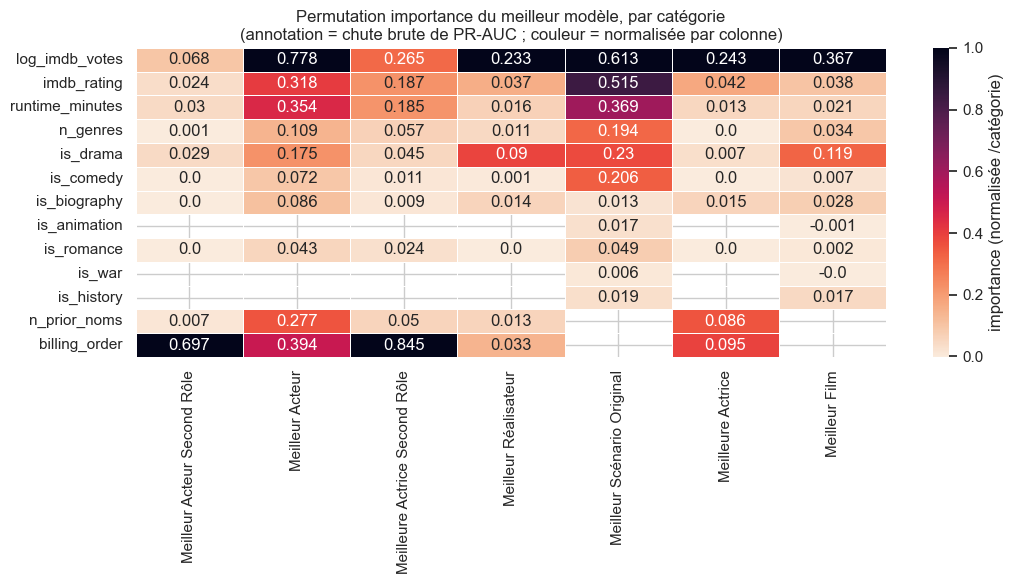

In [12]:
from sklearn.inspection import permutation_importance

ALL_FEATS = ["log_imdb_votes", "imdb_rating", "runtime_minutes", "n_genres", "is_drama",
             "is_comedy", "is_biography", "is_animation", "is_romance", "is_war", "is_history",
             "n_prior_noms", "billing_order"]
imp = pd.DataFrame(index=ALL_FEATS, dtype=float)

for cat, ds in nomination_df.groupby("category"):
    feats = FILM_FEATS if ds.kind.iloc[0] == "film" else PERSON_FEATS
    X = ds[feats].apply(lambda c: pd.to_numeric(c, errors="coerce")).astype(float); X = X.fillna(X.median())
    y = ds.nominated.astype(int).values
    best_name = synth.loc[cat, "best_modèle"]
    model = build_model(best_name)
    if best_name in _NEED_SW:
        model.fit(X, y, sample_weight=compute_sample_weight("balanced", y))
    else:
        model.fit(X, y)
    r = permutation_importance(model, X, y, scoring="average_precision",
                               n_repeats=8, random_state=RNG, n_jobs=-1)
    imp.loc[feats, cat] = r.importances_mean

imp = imp.reindex(columns=overview.index)
imp_norm = imp.div(imp.max(axis=0), axis=1)   # normalisé par catégorie (0–1) pour comparer les couleurs

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(imp_norm, annot=imp.round(3), fmt="", cmap="rocket_r", linewidths=.5,
            cbar_kws={"label": "importance (normalisée /catégorie)"},
            mask=imp.isna(), ax=ax)
ax.set_title("Permutation importance du meilleur modèle, par catégorie\n"
             "(annotation = chute brute de PR-AUC ; couleur = normalisée par colonne)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()


## 10. Visualisations de synthèse

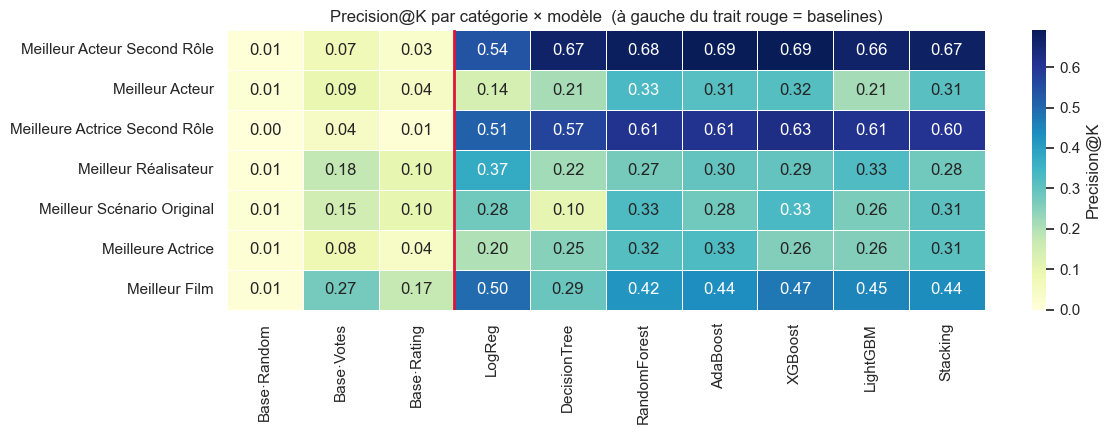

In [13]:
# (A) Heatmap Precision@K — catégorie × modèle
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5,
            cbar_kws={"label": "Precision@K"}, ax=ax)
ax.axvline(len(BASELINES), color="crimson", lw=2)   # frontière baselines | ML
ax.set_title("Precision@K par catégorie × modèle  (à gauche du trait rouge = baselines)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()


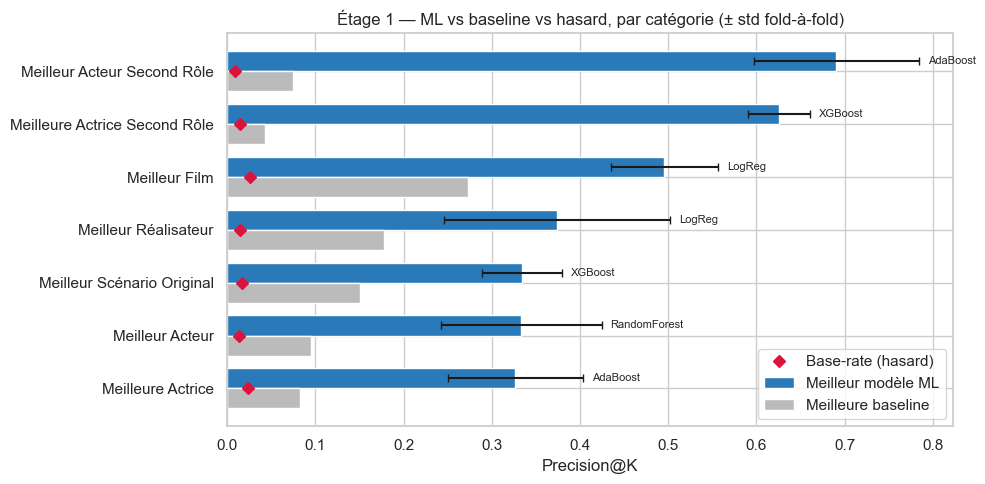

In [14]:
# (B) Meilleur ML vs meilleure baseline vs base-rate, par catégorie (avec barres d'erreur ± std)
s = synth.sort_values("P@K", ascending=True)
yk = np.arange(len(s)); h = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(yk + h/2, s["P@K"], h, xerr=s["± std"], capsize=3, label="Meilleur modèle ML", color="#2a7ab9")
ax.barh(yk - h/2, s["P@K_baseline"], h, label="Meilleure baseline", color="#bbbbbb")
ax.plot(s["base_rate"], yk, "D", color="crimson", label="Base-rate (hasard)", zorder=5)
for i, (p, m) in enumerate(zip(s["P@K"], s["best_modèle"])):
    ax.text(p + s["± std"].iloc[i] + .01, yk[i] + h/2, m, va="center", fontsize=8)
ax.set_yticks(yk); ax.set_yticklabels(s.index)
ax.set_xlabel("Precision@K"); ax.set_title("Étage 1 — ML vs baseline vs hasard, par catégorie (± std fold-à-fold)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


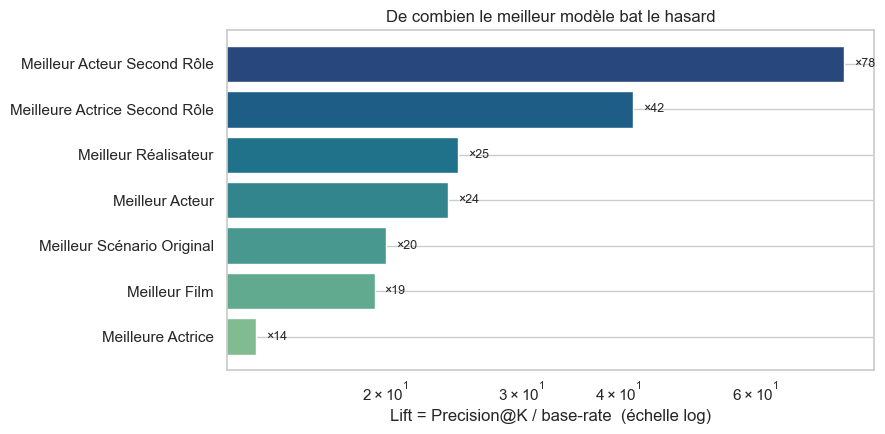

In [15]:
# (C) Lift du meilleur modèle (× combien on bat le hasard) — échelle log
s2 = synth.sort_values("lift")
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(s2.index, s2["lift"], color=sns.color_palette("crest", len(s2)))
ax.set_xscale("log")
for b, v in zip(bars, s2["lift"]):
    ax.text(v * 1.03, b.get_y() + b.get_height()/2, f"×{v:.0f}", va="center", fontsize=9)
ax.set_xlabel("Lift = Precision@K / base-rate  (échelle log)")
ax.set_title("De combien le meilleur modèle bat le hasard")
plt.tight_layout(); plt.show()


## 11. Interprétation métier

Quatre enseignements transversaux, lus à la croisée du benchmark (§7) et de l'importance des
features (§9) :

**1. Les baselines ne gagnent jamais — mais elles ne sont pas nulles.** Ranker par *nombre de votes
IMDb* est déjà un proxy honnête d'« exposition » : un film que personne n'a vu ne sera pas nominé.
Le ML ajoute la *forme* du signal (genre prestige, billing, historique) que le seul volume ignore —
d'où le `lift_vs_base` positif partout (§7.3).

**2. Les seconds rôles se prédisent bien mieux que les premiers rôles.** Le pattern « vétéran·e dans
un film acclamé » (`n_prior_noms` + `imdb_rating` élevés — confirmé par la permutation importance)
est un signal net que les ensembles d'arbres captent. Les **catégories Leading** sont plus dures :
la course y est plus *politique* (campagnes, narratifs de carrière), moins lisible dans les seules
features IMDb/TMDb — d'où une P@K plus basse et un `± std` plus large.

**3. Catégories « film » = terrain du feature engineering.** *Best Picture* et *Scénario Original*
s'appuient sur l'exposition + les genres ; le signal est largement **additif**, ce qui explique
qu'un modèle linéaire (LogReg) ou un boosting/stacking y soit compétitif tout en restant le plus
**interprétable** — un atout en soutenance.

**4. Théorie vs empirie (§7.2).** Quand le pari du notebook 04 ne « gagne » pas, l'écart est
généralement dans le bruit fold-à-fold (`± std`) : le pari reste défendable. Les divergences nettes
sont elles-mêmes instructives (un ensemble d'arbres ramasse des interactions qu'on n'avait pas
anticipées sur les catégories personne).

> ⚠️ **Limite assumée** : le modèle récompense la **traction IMDb**, pas le prestige/la langue.
> Il *rate* certains films étrangers nominés (faible volume de votes) et peut sur-classer un
> blockbuster populaire mais snobé. C'est le prix d'un set de features volontairement *connu avant
> les nominations* et sans fuite (§8).


## 12. Conclusion

- **Le ML bat le hasard dans les 7 catégories** (lift ×13 à ×78) et **aucune baseline ne domine** le
  meilleur modèle ML (§7.3) — la modélisation par catégorie est justifiée.
- **Pas de modèle universel** : le champion varie (linéaire pour les catégories « film » au signal
  additif, ensembles d'arbres / boosting pour les « personne »). On garde **un modèle par catégorie**.
- **Évaluation défendable** : métriques agrégées *entre folds* (P@K ± std), validation temporelle
  `GroupKFold(year)`, et auto-check anti-leakage au vert (§8).
- **Livrables** : `oscar_nomination_dataset.parquet` (7 catégories, set négatif B+) +
  `benchmark_nomination_models.csv` (table complète catégorie × modèle).

Une fois la *shortlist* de nominés établie, la prédiction **du gagnant parmi les nominés** (étage 2,
bonus) est traitée dans [`06_Winner_modeling.ipynb`](06_Winner_modeling.ipynb) : problème plus
équilibré (base-rate 13–26 %) mais aux signaux plus subtils (momentum des guildes, narratifs).
